In [39]:
import json
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.readwrite import json_graph

In [40]:
df = pd.read_csv("cluster_metrics.csv")
df["amplitude"] = df["cluster_mean_node_rho"] - df["city_mean_node_rho"]

In [41]:
CBSA_TO_AREA = {16980: 1714000, 37980: 4260000}

cluster_labels = (
    pd.read_csv("auto_cluster_tracts.csv")[["cbsa", "cluster", "cluster_title"]]
    .drop_duplicates()
    .assign(area_code=lambda x: x["cbsa"].map(CBSA_TO_AREA))
    [["area_code", "cluster", "cluster_title"]]
)

df = df.merge(cluster_labels, on=["area_code", "cluster"], how="left")


In [42]:
groups = {key: group for key, group in df.groupby(["area_code", "cluster"])}
CBSA_CONFIG = {1714000: "Chicago", 4260000: "Philadelphia"}
groups = {key: group for key, group in df[df["area_code"].isin(CBSA_CONFIG)].groupby(["area_code", "cluster"])}

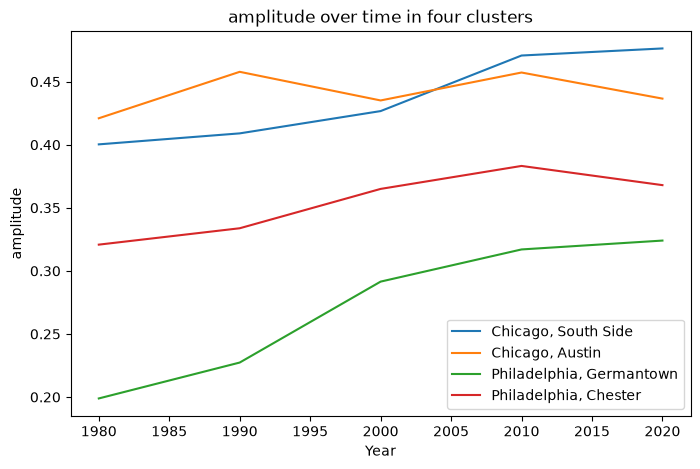

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
metric = "amplitude"
for (area_code, cluster), group in groups.items():
    g = group.sort_values("year")
    ax.plot(g["year"], g[metric], label=g["cluster_title"].iloc[0])

ax.set_xlabel("Year")
ax.set_ylabel(metric)
ax.legend()
plt.title(f"{metric} over time in four clusters")
fig.savefig(f"../figures/{metric} over time in four clusters", dpi=150, bbox_inches="tight")
plt.show()